In [1]:
import pandas as pd
import numpy as np
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil
from functools import reduce

import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LogisticRegression, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, StratifiedKFold
import statsmodels.stats.api as stm
import statsmodels.api as sm
from sklearn.utils.class_weight import compute_class_weight

# for survival analysis
import lifelines
from epi_utils import *
from datetime import datetime

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETA",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMI",
                  "Pretomanid": "PTM",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LEV",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

# 7H10 critical concentrations dictionary
cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100}

cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_WHO_catalog.csv")

drugs_lst = ['RIF', 'INH', 'EMB', 'PZA']

who_variants = pd.read_csv("../../data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']

# MIC encoding from the TRUST codebook
MIC_encoding_dicts = {'RIF': {1: '0,0.03', 2: '0.03,0.06', 3: '0.06,0.125', 4: '0.125,0.25', 5: '0.25,0.5', 6: '0.5,1', 7: '1,inf'},
                      'INH': {1: '0,0.025', 2: '0.025,0.05', 3: '0.05,0.1', 4: '0.1,0.2', 5: '0.2,inf'},
                      'EMB': {1: '0,0.6', 2: '0.6,1.25', 3: '1.25,2.5', 4: '2.5,5', 5: '5,inf'},
                      'PZA': {1: '0,25', 2: '25,50', 3: '50,75', 4: '75,100', 5: '100,inf'}
                     }

isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

In [2]:
# this is all 452 patients, no exclusions based on the availability of WGS or validity for the TCC analysis
df_full = pd.read_csv("raw_data/20240826_metadata_MIC_method_updates.csv")

# this is all WGS samples that we have matched with patients, not just WGS at baseline
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")

In [3]:
df_full = add_household_numbers(df_full)
df_full.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

82 patients share a household with another patient, accounting for 32 households
402 unique households across 452 patients


array([4, 2, 3, 6, 5])

In [4]:
df_TTP_smear, df_TCC, df_combined_culture_results = get_combined_culture_results(df_full)
print(f"{df_TCC.pid.nunique()} pids for the TCC analysis")
print(f"{df_TTP_smear.dropna(subset='culture_sample_num').query('culture_sample_num <= 5').pid.nunique()} pids with baseline TTPs within the first 5 weeks")

391 pids for the TCC analysis
409 pids with baseline TTPs within the first 5 weeks


In [98]:
df_trust_patients, TRUST_phenos, df_pred_combined =  read_combine_all_TRUST_data("./processed_data/combined_patients_WGS_samples.csv", CNN_results_dir="/n/data1/hms/dbmi/farhat/Sanjana/CNN_results", baseline_only=True)

418 patients with any WGS samples
416 patients with uncontaminated WGS samples
404 patients with uncontaminated WGS samples taken in the first 2 weeks

2 patients: ['T0137' 'T0402'] have multiple sequences at the same timepoint
Removing 1 patients: ['T0402'] because there are multiple WGS samples at the same timepoint with different lineages
405 patients have MICs for RIF
405 patients have MICs for INH
405 patients have MICs for EMB
284 patients have MICs for PZA
401 patients have measured MICs in the first 2 weeks

Found predicted RIF MICs for 403 pids
Found predicted INH MICs for 403 pids
Found predicted EMB MICs for 403 pids
Found predicted PZA MICs for 403 pids
403 patients have predicted MICs


In [6]:
# also run on this so that the variables are in better encodings
df_trust_patients = process_patient_metadata_better_encodings(df_trust_patients, TRUST_phenos, df_TTP_smear=None, include_TTP=False)
df_trust_patients.pid.nunique()

403

In [7]:
# just to get the counts
df_trust_patients = add_household_numbers(df_trust_patients)
df_trust_patients.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

68 patients share a household with another patient, accounting for 31 households
366 unique households across 403 patients


array([4, 2, 3, 1, 6])

In [8]:
pli_predictions = get_percent_long_involvement_predictions()
print(pli_predictions.outlier.value_counts())

453 total pids
outlier
0    406
1     47
Name: count, dtype: int64


In [9]:
df_full = add_household_numbers(df_full)
df_full.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

82 patients share a household with another patient, accounting for 32 households
402 unique households across 452 patients


array([4, 2, 3, 6, 5])

In [10]:
# just to get the counts
df_trust_patients = add_household_numbers(df_trust_patients)
df_trust_patients.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique()

68 patients share a household with another patient, accounting for 31 households
366 unique households across 403 patients


array([4, 2, 3, 1, 6])

In [13]:
# sns.histplot(df_trust_patients[['pid', 'bl_cd4', 'bl_hiv', 'bl_art']].dropna(),
#              x='bl_cd4',
#              # hue='bl_art',
#              # multiple='dodge',
#              # stat='probability',
#             )

# sns.despine()
# plt.show()

In [7]:
# # contaminated for RIF MIC is 8
# drug = 'RIF'

# for col in [f's_{drug.lower()}mic_sputum_specimen_1', f's_{drug.lower()}mic_sputum_specimen_2']:
#     print(col, len(df_trust_patients.query(f"{col}==8")))

In [8]:
# # contaminated the other 3 drug MICs is 6
# for drug in ['INH', 'EMB', 'PZA']:
#     for col in [f's_{drug.lower()}mic_sputum_specimen_1', f's_{drug.lower()}mic_sputum_specimen_2']:
#         print(col, len(df_trust_patients.query(f"{col}==6")))

In [11]:
def compute_difference_between_dates(df, col_1, col_2, new_col_name):

    df[new_col_name] = df[col_1] - df[col_2]

    # convert to float days
    df[new_col_name] = df[new_col_name].dt.total_seconds() / 60 / 60 / 24

    return df
    
        
def process_dates_table(df_full, dates_fName):

    df_dates = pd.read_csv(dates_fName)
    
    # skip first column, which is pid, and convert the rest to datetime format
    for col in df_dates.columns[1:]:
        df_dates[col] = pd.to_datetime(df_dates[col], format='%m/%d/%Y')
    
        if " " in col:
            df_dates.rename(columns={col: col.replace(' ', '_')}, inplace=True)

    # combine with the treatment outcomes for easy look up
    df_dates = df_dates.merge(df_full[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti', 'esp_cod_end_of_study_parti']], on='pid')
        
    # treatment duration
    df_dates = compute_difference_between_dates(df_dates, 'Treatment_Completion_Date', 'Date_of_Treatment_Initiation', 'tx_duration')
    
    # time between screening date and tx completion date. It's usually the same as tx_duration but sometimes screening date and tx initiation date are not the same
    df_dates = compute_difference_between_dates(df_dates, 'Treatment_Completion_Date', 'Screen_Date', 'tx_completion_time')
    
    # to_comments_treatment_outcome = 'Participant died on 25/09/2021, last clinic appointment 16/04/2021'
    df_dates.loc[df_dates['pid']=='T0252', 'Date_of_Death'] = datetime(2021, 9, 25)
    
    # to_comments_treatment_outcome = 'Cause of death unknown. Participant died 12/10/2021'
    df_dates.loc[df_dates['pid']=='T0274', 'Date_of_Death'] = datetime(2021, 10, 12)

    # pulled from RedCap notes by Sue and the field team
    df_dates.loc[df_dates['pid']=='T0248', 'Date_of_Death'] = datetime(2021, 5, 22)
    df_dates.loc[df_dates['pid']=='T0240', 'Date_of_Death'] = datetime(2022, 8, 28)
    df_dates.loc[df_dates['pid']=='T0137', 'Date_of_Death'] = datetime(2019, 2, 14)
    df_dates.loc[df_dates['pid']=='T0318', 'Date_of_Death'] = datetime(2022, 9, 11)

    # this one is discrepant. Currently they said to use 17-06-2022, but something is still off because why would pid T0274 have a 6-month outcome of death in that case
    df_dates.loc[df_dates['pid']=='T0274', 'Date_of_Death'] = datetime(2022, 6, 17)
    
    # date of death relative to screening date
    df_dates = compute_difference_between_dates(df_dates, 'Date_of_Death', 'Screen_Date', 'dod')

    # because some dates were entered manually, check the accuracy. Can't be before the initial screening date
    assert len(df_dates.query("dod < 0")) == 0

    return df_dates

In [12]:
def get_reenrollments_same_lineage(df_full, df_dates, lineage_col='Coll2014'):

    # so far, same results if you take primary lineage as the comparator

    # get all pairs of pids that are re-enrollments. This includes the patient who enrolled 3 times split across 3 lines
    df_reenroll = get_reenrolled_patients(df_full)
    print(len(df_reenroll))
    
    df_reenroll_with_dates = df_reenroll.merge(df_dates[['pid', 'Screen_Date']].rename(columns={'Screen_Date': 'pid_screen_date'}), how='left').merge(df_dates[['pid', 'Screen_Date']].rename(columns={'pid': 'screen_prevpid', 'Screen_Date': 'screen_prevpid_screen_date'}), how='left')
    
    # check that the new screening date is always later than the previous one
    assert len(df_reenroll_with_dates.query("pid_screen_date < screen_prevpid_screen_date")) == 0
    
    # compute the difference in days between the date each patient was screened and rescreened
    df_reenroll_with_dates['screening_diff'] = df_reenroll_with_dates['pid_screen_date'] - df_reenroll_with_dates['screen_prevpid_screen_date']
    
    # convert to float days. The difference above is in default seconds
    df_reenroll_with_dates['screening_diff'] = df_reenroll_with_dates['screening_diff'].dt.total_seconds() / 60 / 60 / 24

    # get all the WGS samples, not just those collected at baseline
    df_trust_patients_all = get_combined_patient_WGS_data_only("./processed_data/combined_patients_WGS_samples.csv")

    # preferentially keep....okay not sure because of the T0267/T0066 difference. Both times, the person went from having 2.2.1.1./4.3.2.1 mixture at the baseline WGS to 2.2.1.1 only
    df_trust_patients_all = df_trust_patients_all.sort_values("SampleID").drop_duplicates('pid', keep='first')

    df_reenroll_with_dates_lineages = df_reenroll_with_dates.merge(df_trust_patients_all[['pid', 'SampleID', lineage_col, 'F2']], how='left').merge(df_trust_patients_all[['pid', 'SampleID', lineage_col, 'F2']].rename(columns={'pid': 'screen_prevpid', 'SampleID': 'prevpid_SampleID', lineage_col: f'prevpid_{lineage_col}', 'F2': 'prevpid_F2'}), how='left')

    # nothing should have been dropped here
    # assert len(df_reenroll_with_dates_lineages) == len(df_reenroll)

    # separate patients we can confirm had the same lineage from others. This will necessarily drop patients who had sequencing of 1 or neither sample
    df_reenroll_same_lineage = df_reenroll_with_dates_lineages.dropna().query(f"{lineage_col} == prevpid_{lineage_col}")

    df_reenroll_unknown_or_diff_lineages = df_reenroll_with_dates_lineages.query("pid not in @df_reenroll_same_lineage.pid")

    return df_reenroll_same_lineage, df_reenroll_unknown_or_diff_lineages

In [13]:
# this is all WGS samples that we have matched with patients, not just WGS at baseline
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/clinical_data/20241127_combined_patients_WGS_samples.csv")

df_dates = process_dates_table(df_full, "raw_data/TRUST_Dates_10.29.24.csv")

df_final = pd.read_csv("./processed_data/tx_outcomes_table.csv")

In [14]:
# df_WHO_variants = []
# failed_samples = []

# for sampleID in df_full_WGS.SampleID.values:

#     WHO_variants_fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sampleID}/WHO_resistance/{sampleID}_variants_annot.tsv"

#     if os.path.isfile(WHO_variants_fName):
#         df = pd.read_csv(WHO_variants_fName, sep='\t')
#         df['SampleID'] = sampleID
#         df_WHO_variants.append(df.query("confidence=='1) Assoc w R'"))
#     else:
#         # some don't have FASTQs. If they do, they must be highly contaminated
#         if os.path.isdir(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sampleID}"):
#             failed_samples.append(sampleID)

# df_WHO_variants = pd.concat(df_WHO_variants)

In [15]:
df_summary = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")
pids_Marie = np.unique(np.concatenate([df_full.pid.values, pd.read_csv("./TRUST_IDs_Marie.csv")['pid'].values]))
print(len(pids_Marie))

df_Marie = df_full_WGS.query("pid in @pids_Marie")[['pid', 'SampleID']].merge(df_summary.dropna(subset='Median_Depth'))
df_Marie.Median_Depth.min(), df_Marie.Median_Depth.max()

454


(232.0, 956.0)

In [17]:
# def extract_TRUST_WHO_variant_annotations(df, name_col):

#     df_add = []
    
#     for sample in df[name_col].unique():

#         fName = f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sample}/WHO_resistance/{sample}_variants_annot.tsv"

#         if os.path.isfile(fName):
        
#             df_pred = pd.read_csv(fName, sep='\t')
#             df_pred[name_col] = sample
#             df_add.append(df_pred)
    
#     df_add = pd.concat(df_add)
    
#     return df_add
    
    
# df_TRUST_variants = extract_TRUST_WHO_variant_annotations(df_full_WGS, 'SampleID')

# df_INH_variants = df_TRUST_variants.query("drug=='Isoniazid'").merge(df_full_WGS[['pid', 'Original_ID', 'SampleID']], on='SampleID', how='right').set_index(['pid', 'Original_ID', 'SampleID']).reset_index()

In [18]:
# # combine with the full dataframe of WGS, but only those that are uncontaminated
# df_send = pd.DataFrame({'pid': pids_Marie}).merge(df_full_WGS.dropna(subset='Lineage')[['pid', 'Original_ID', 'SampleID']], on='pid', how='left')

# df_send.loc[pd.isnull(df_send['SampleID']), 'WGS'] = 0
# df_send['WGS'] = df_send['WGS'].fillna(1).astype(int)

# for i, row in df_send.iterrows():
    
#     if not pd.isnull(row['Original_ID']):

#         split_name = row['Original_ID'].split('-')[1]
        
#         if split_name == 'm5':
#             df_send.loc[i, 'specimen_time_point'] = 13
#         elif split_name == '01A':
#             df_send.loc[i, 'specimen_time_point'] = 15
#         else:
#             df_send.loc[i, 'specimen_time_point'] = int(split_name)

# print(df_send['specimen_time_point'].unique())

# print(df_INH_variants.GENE.unique())

# # add INH variants, only katG, ahpC, and fabG1-inhA
# df_send = df_send.merge(df_INH_variants.loc[df_INH_variants["GENE"].isin(['katG', "oxyR'-ahpC", 'ahpC', 'Rv1482c-fabG1', 'fabG1', 'inhA'])][['SampleID', 'GENE', 'variant', 'confidence']], on='SampleID', how='left').sort_values(['pid', 'specimen_time_point'])

# df_send.loc[df_send['confidence'].isin(['1) Assoc w R', '2) Assoc w R - Interim']), 'resistance_assoc'] = 1
# df_send['resistance_assoc'] = df_send['resistance_assoc'].fillna(0)

# df_send.loc[pd.isnull(df_send['confidence']), 'resistance_assoc'] = np.nan

# # df_send_drop_duplicates = df_send.drop_duplicates(subset='pid', keep='first')
# df_send.to_csv("INH_variants_TRUST.csv", index=False)
# print(df_send.pid.nunique())

# Re-Enrollments

In [19]:
df_reenroll_same_lineage, df_reenroll_unknown_or_diff_lineages = get_reenrollments_same_lineage(df_full, df_dates)

print(len(df_reenroll_same_lineage), len(df_reenroll_unknown_or_diff_lineages))

19
418 patients with any WGS samples
416 patients with uncontaminated WGS samples
11 8


In [67]:
df_reenroll_same_lineage

,pid,screen_prevpid,pid_screen_date,screen_prevpid_screen_date,screening_diff,SampleID,Coll2014,F2,prevpid_SampleID,prevpid_Coll2014,prevpid_F2
0,T0254,T0210,2021-02-05,2019-12-18,415.0,MFS-169,2.2.1.1,0.010958,MFS-638,2.2.1.1,0.011425
1,T0267,T0066,2021-05-07,2018-05-07,1096.0,MFS-270,2.2.1.1,0.245979,MFS-39,2.2.1.1,0.110925
5,T0330,T0257,2022-02-17,2021-03-04,350.0,MFS-395,4.1.1.1,0.006105,MFS-174,4.1.1.1,0.008193
6,T0336,T0249,2022-04-25,2021-01-05,475.0,MFS-406,2.2.1,0.010594,MFS-162,2.2.1,0.009529
7,T0340,T0176,2022-06-08,2019-07-19,1055.0,MFS-414,2.2.1.1,0.010344,MFS-93,2.2.1.1,0.011959
9,T0363,T0130,2022-09-01,2018-12-11,1360.0,MFS-448,2.2.1.1,0.009318,MFS-62,2.2.1.1,0.009158
12,T0387,T0210,2022-11-25,2019-12-18,1073.0,MFS-480,2.2.1.1,0.010592,MFS-638,2.2.1.1,0.011425
13,T0387,T0254,2022-11-25,2021-02-05,658.0,MFS-480,2.2.1.1,0.010592,MFS-169,2.2.1.1,0.010958
14,T0424,T0115,2023-05-19,2018-10-30,1662.0,MFS-694,2.2.1,0.009814,MFS-575,2.2.1,0.010152
15,T0435,T0089,2023-06-27,2018-07-20,1803.0,MFS-700,2.2.1.1,0.009888,MFS-54,2.2.1.1,0.010112


In [20]:
df_reenroll_same_lineage.screening_diff.max()

1803.0

In [21]:
# df_reenroll_same_lineage[['screen_prevpid', 'screen_prevpid_screen_date', 'prevpid_Coll2014', 'prevpid_F2', 'pid', 'pid_screen_date', 'Coll2014', 'F2']].to_csv("reenroll_same_lineages.csv", index=False)

In [16]:
# df_reenroll_unknown_or_diff_lineages[['screen_prevpid', 'screen_prevpid_screen_date', 'prevpid_Coll2014', 'prevpid_F2', 'pid', 'pid_screen_date', 'Coll2014', 'F2']].to_csv("reenroll_not_same_lineages.csv", index=False)

In [20]:
# df_fastlin_combined = []

# for sample_id in df_full_WGS.query("pid in ['T0066', 'T0267']").SampleID.values:

#     df_fastlin_combined.append(pd.read_csv(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/{sample_id}/{sample_id}/fastlin/output.txt", sep='\t'))

# df_fastlin_combined = pd.concat(df_fastlin_combined)

In [21]:
# df_reenroll_same_lineage.merge(df_full[['pid', 'esp_reason_end_of_study_parti']].rename(columns={'pid': 'screen_prevpid'}))[['screen_prevpid_screen_date', 'pid_screen_date', 'Coll2014', 'esp_reason_end_of_study_parti']].sort_values("esp_reason_end_of_study_parti").to_csv("/home/sak0914/reenroll_patients_same_lineages.csv", index=False)

In [22]:
# df_fastlin_save = []

# for sample_id in ['MFS-39', 'MFS-40', 'MFS-270', 'MFS-280']:

#     df_fastlin = pd.read_csv(f"/n/scratch/users/s/sak0914/TRUST_variant_calling/{sample_id}/{sample_id}/fastlin/output.txt", sep='\t')
#     df_fastlin = df_fastlin[['#sample', 'k_cov', 'mixture', 'lineages']].rename(columns={'#sample': 'SampleID'})
#     df_fastlin_save.append(df_fastlin)

# df_fastlin_save = pd.concat(df_fastlin_save)

In [23]:
# do the re-enrolled patients with the same lineage have shorter time to relapse?
# ooh, p-value < 0.1 but not < 0.05
st.mannwhitneyu(df_reenroll_same_lineage['screening_diff'],
                df_reenroll_unknown_or_diff_lineages['screening_diff'], # include all cases that we can't confirm are the same lineage
                alternative='less'
               )

MannwhitneyuResult(statistic=28.0, pvalue=0.10300071445582282)

In [24]:
# do the re-enrolled patients with the same lineage have shorter time to relapse?
st.mannwhitneyu(df_reenroll_same_lineage['screening_diff'],
                df_reenroll_unknown_or_diff_lineages.dropna()['screening_diff'], # drop NaNs, which are cases we don't know the lineage for because there's no WGS
                alternative='less'
               )

MannwhitneyuResult(statistic=11.0, pvalue=0.08864468864468865)

In [25]:
len(df_reenroll_same_lineage), len(df_reenroll_unknown_or_diff_lineages)

(11, 8)

# Rifampicin AUCs from Marie

In [22]:
df_RIF_AUC = pd.read_csv("processed_data/RIF_AUC_from_Marie.csv")

for i, row in df_RIF_AUC.iterrows():

    if row['ID'] < 10:
        df_RIF_AUC.loc[i, 'pid'] = f"T000{int(row['ID'])}"
    elif row['ID'] < 100:
        df_RIF_AUC.loc[i, 'pid'] = f"T00{int(row['ID'])}"
    else:
        df_RIF_AUC.loc[i, 'pid'] = f"T0{int(row['ID'])}"

# espR Indels

In [19]:
# espR_indel_data = []

# vcf_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/espR_indels"

# fNames = glob.glob(f"{vcf_dir}/*.tsv")

# for fName in fNames:

#     try:
#         df_indels = pd.read_csv(fName, sep='\t')
    
#         if len(df_indels) > 0:
    
#             df_indels['SampleID'] = os.path.basename(fName).split('.')[0]
#             espR_indel_data.append(df_indels)
#     except:
#         print(f"Not finished {fName}")

# espR_indel_data = pd.concat(espR_indel_data).reset_index(drop=True)#.merge(df_trust_patients[['pid', 'SampleID']], on='SampleID')

# # check to see if any samples have multiple indels
# print(f"{espR_indel_data.SampleID.nunique()} samples have {len(espR_indel_data)} indels in espR")

# # add to df_trust_patients
# df_trust_patients.loc[df_trust_patients['SampleID'].isin(espR_indel_data.SampleID), 'espR_indel'] = 1
# df_trust_patients['espR_indel'] = df_trust_patients['espR_indel'].fillna(0)
# df_trust_patients.loc[pd.isnull(df_trust_patients['Lineage']), 'espR_indel'] = np.nan

In [20]:
# df_trust_patients.espR_indel.value_counts(dropna=False)

In [21]:
# this is the one person with an espA indel
# df_final.query("pid=='T0113'")

In [23]:
# to_studyto_treatment_outcome column. 
# Other descriptions in to_studyto_other_treatment_outcome
# additional comments in to_comments_treatment_outcome
treatment_outcome_dict = {1: 'cure',
                          2: 'complete',
                          3: 'defaulted', # typically they stopped taking treatment entirely, not just interruption. May have been doctor-recommended, like due to liver injury or something
                          4: 'failure',
                          5: 'extension',
                          6: 'death',
                          7: 'transferred',
                          8: 'lost_fu',
                          9: 'other'
                        }

# esp_reason_end_of_study_parti column
# Other descriptions in esp_reasonoth_end_of_study_parti
esp_dict = {1: 'complete', # completed all study requirements
            2: 'inappropriate', # should not have been included in the study
            3: 'withdrew',
            4: 'failure', # includes both groups 4 and 5 in treatment_outcome_dict, meaning the patient was culture positive at month 5 or tx was extended
            5: 'relapse',
            6: 'moved', # moved/transferred out,
            7: 'lost_fu',
            8: 'death',
            9: 'other'
            }

In [24]:
def get_dictionary_mapping_months_to_cols(cols_lst):

    cols_dict = {}
    
    for name in cols_lst:
        month = int(name.split('_')[-1].replace('mo', ''))
        cols_dict[month] = name
    
    # sort by month, descending. Need to iterate through them descending to get the latest completed follow-up
    cols_dict = {key: cols_dict[key] for key in sorted(cols_dict.keys())[::-1]}

    return cols_dict


during_tx_fu_cols = df_full.columns[(df_full.columns.str.startswith('fu_date_treatment')) & (df_full.columns.str.endswith('mo'))]
post_tx_fu_cols = df_full.columns[(df_full.columns.str.startswith('tlfb_date')) & (df_full.columns.str.contains('posttreatment'))]

during_tx_fu_cols_dict = get_dictionary_mapping_months_to_cols(during_tx_fu_cols)
post_tx_fu_cols_dict = get_dictionary_mapping_months_to_cols(post_tx_fu_cols)


def get_last_date_of_fu(df, pid, cols_dict):

    found_last_follow_up = False

    # check the post-tx appointments first, then the during-tx appointments. 
    # There are some cases where the patients have a 6-month treatment outcome, but they haven't come for post-tx follow-up appointments yet
    for col_name in cols_dict.values():
            
        if not found_last_follow_up:
            
            latest_date = df.query("pid==@pid")[col_name].values[0]
            
            if not pd.isnull(latest_date):
                found_last_follow_up = True    

    if found_last_follow_up:
        return latest_date
    else:
        return None

In [25]:
def compute_death_relative_days(df, df_dates):
    '''
    All dates are relative to the screening date in units of days.
    '''

    # known_dod_dict = dict(zip(df[['pid', 'esp_dod_end_of_study_parti']].dropna()['pid'], df[['pid', 'esp_dod_end_of_study_parti']].dropna()['esp_dod_end_of_study_parti']))

    # df_deaths from Sue has 3 more patients than df_full. Also checked that all the death dates match between the two dataframes for the other 11
    known_dod_dict = dict(zip(df_dates.dropna(subset='dod')['pid'], df_dates.dropna(subset='dod')['dod']))  

    # if the waiver specifies death, then they must also have a death in the dataframe of deaths that Sue sent. Otherwise, it's likely that their death occurred after leaving the trial
    died_pids = df.query("to_studyto_treatment_outcome==6 | esp_reason_end_of_study_parti == 8 | (waiver_reason_end_of_study_parti == 4 & pid in @known_dod_dict.keys())").pid.unique()

    # add a column annotating TB-attributable deaths
    tb_death_pids = []
    non_tb_death_pids = []

    # check these descriptor columns for TB-related strings
    for col in ['esp_cod_end_of_study_parti', 'waiver_deathcause_end_of_study_parti']:
        
        tb_death_pids += list(df.dropna(subset=col).query(f"{col}.str.contains('|'.join(['pulmonary', 'ashtma', 'asthma', 'tuberc', 'embolism']), case=False)").pid.values)

        # manually add from additional data that Sue sent on December 3, 2024. T0318 died of MDR, so check that they aren't in the study
        tb_death_pids += ['T0240', 'T0318']

        non_tb_death_pids += list(df.dropna(subset=col).query(f"{col}.str.contains('|'.join(['cancer', 'heart', 'attack', 'accident', 'covid']), case=False)").pid.values)        
    
    df_death_events = pd.DataFrame()
    
    # the two columns esp_dod_end_of_study_parti and waiver_deathdate_end_of_study_parti are the same for all patients
    # so arbitrarily use esp_dod_end_of_study_parti as the date
    # there are 18/32 patients without a date of death currently. The only patients with a date of death are those with esp_reason_end_of_study_parti = 8
    # found 2 in the to_comments column
    
    df_death_events['pid'] = died_pids
    df_death_events['date'] = df_death_events['pid'].map(known_dod_dict)

    # add outcomes to use them for checking
    df_death_events = df_death_events.merge(df[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_date_end_of_study_parti', 'waiver_reason_end_of_study_parti', 'esp_cod_end_of_study_parti', 'waiver_deathcause_end_of_study_parti']], on='pid', how='left')

    # df_death_events = df_death_events.set_index('pid')

    # for the ones without dates according to the dataframe above, take the last appointment date
    # every patient with ESP = death has a value in df_deaths from Sue, which matches esp_dod_end_of_study_parti BUT NOT esp_date_end_of_study_parti
    
    # for pid in df_death_events.loc[pd.isnull(df_death_events['date'])].index.unique():
    for i, row in df_death_events.iterrows():

        if pd.isnull(row['date']):
            
            # the missing ones must have to_studyto_treatment_outcome = 6 because we already required a date to be present if waiver_reason_end_of_study_parti = 4
            # and already checked that all patients with esp_reason_end_of_study_parti = 8 have a death date
            assert row['to_studyto_treatment_outcome'] == 6
    
            # so get the last appointment during the 6 months of treatment
            latest_date = get_last_date_of_fu(df, row['pid'], during_tx_fu_cols_dict)
    
            if latest_date is not None:
                df_death_events.loc[i, 'date'] = latest_date

            # if no follow-up appointment date found, then take the ESP date
            # little bit weird not to censor these patients, but they are known to have a 6 month outcome of death
            else:
                latest_date = row['esp_date_end_of_study_parti']

                if pd.isnull(latest_date):
                    raise ValueError(f"No last date of contact or follow-up found for {row['pid']}")
                else:
                    df_death_events.loc[i, 'date'] = latest_date

    df_death_events['event_type'] = 'death'

    # df_death_events.loc[df_death_events['pid'].isin(tb_death_pids), 'TB_death'] = 1
    # df_death_events['TB_death'] = df_death_events['TB_death'].fillna(0).astype(int)
    
    df_death_events.loc[df_death_events['pid'].isin(non_tb_death_pids), 'TB_death'] = 0
    df_death_events['TB_death'] = df_death_events['TB_death'].fillna(1).astype(int)
    
    return df_death_events.set_index('pid')

In [26]:
def compute_relapse_relative_days(df, df_reenroll_same_lineage):
    '''
    Relapse is not a 6 month outcome because it was assessed later.

    For patients whose ESP is relapse, 

    For patients who don't have ESP = relapse, take the date when they were screened for re-enrollment as the relapse date.
    '''
    
    # relapse is only in the esp_reason_end_of_study_parti column. HOWEVER, pids in screen_prevpid also relapsed because they reenrolled.
    # also note that there is a patient (T0328) with the word relapse in waiver_deathcause_end_of_study_parti, but they are not listed as a relapse nor were they reenrolled
    # HOWEVER, they are listed as death in the waiver column, and the description is this. Regardless, they have a death date, so use that, and it's TB-attributable
    relapse_pids = np.unique(np.concatenate([df.query("esp_reason_end_of_study_parti == 5").pid.values,
                                             # df_reenroll.screen_prevpid.values,
                                             df_reenroll_same_lineage.screen_prevpid.values, # restrict to cases where the lineage matches (this is around half of the reenrolled patients) 
                                            ]))

    df_relapse_events = pd.DataFrame(columns = ['pid'])

    screening_diff_dict = dict(zip(df_reenroll_same_lineage['screen_prevpid'], df_reenroll_same_lineage['screening_diff']))

    df_relapse_events['pid'] = relapse_pids

    # some people who re-enrolled also have esp_reason_end_of_study_parti = 5, so the following code will replace their dates
    df_relapse_events['date'] = df_relapse_events['pid'].map(screening_diff_dict)
    
    # all of the people who relapsed completed treatment or were cured in the 6 months (to_studyto_treatment_outcome in [1, 2]), so no need to worry about them i.e. failing tx first
    # so for the remaining patients who were not re-enrolled, take the relapse date to be the last post-tx follow-up appointment they came to 
    df_relapse_events = df_relapse_events.set_index('pid')

    # only get the date of most recent follow-up for patients whose ESP is 5. If they don't have ESP = 5, then take the date of re-enrollment (done above already)
    for pid in df.query("esp_reason_end_of_study_parti == 5").pid.values:
    
        # a single patient -- T0395 -- came for an additional visit. So take that date for the ones that relapse
        addl_visit_date = df.query("pid==@pid")['screen_date_add_additional_visit'].values[0]

        # because they have relapse as their ESP, first check the esp_date_end_of_study_parti column
        if not pd.isnull(addl_visit_date):
            df_relapse_events.loc[pid, 'date'] = addl_visit_date
        else:
            latest_date = df.query("pid==@pid")['esp_date_end_of_study_parti'].values[0]

            if not pd.isnull(latest_date):
                df_relapse_events.loc[pid, 'date'] = latest_date
            # if not found, then take the most recent follow-up date
            # check during the post treatment follow-up stage only because we know they completed treatment
            else:
                latest_date = get_last_date_of_fu(df, pid, post_tx_fu_cols_dict)

                if latest_date is not None:
                    df_relapse_events.loc[pid, 'date'] = latest_date
                else:
                    raise ValueError(f"No follow-up date found for {pid}")

    df_relapse_events['event_type'] = 'relapse'
    df_relapse_events = df_relapse_events.reset_index().merge(df[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_date_end_of_study_parti', 'waiver_reason_end_of_study_parti']], how='left')

    return df_relapse_events.set_index('pid')

In [27]:
def compute_treatment_failure_relative_days(df):
    '''
    This includes patients who had treatment failure, extension, and positive cultures at 5 months
    '''

    # treatment failure or extension at 6 months. Their primary endpoint is the failure, so take the number of days between screen date and tx completion
    df_failure_events = df.query("to_studyto_treatment_outcome in [4, 5]")[['pid']].set_index('pid')

    # take the last completed appointment during the 6-month treatment window. Most of these didn't come to follow-up appointments
    for pid in df_failure_events.index.values:

        # check the during-tx appointments only because these patients didn't complete or had to extend treatment, so restrict to the 6 months
        latest_date = get_last_date_of_fu(df, pid, during_tx_fu_cols_dict)
        
        if latest_date is not None:
            df_failure_events.loc[pid, 'date'] = latest_date
        else:
            raise ValueError(f"No follow-up date found for {pid}")

    # people who had positive month 5 cultures should all meet the criteria above, but check just to make sure
    month5_positive_pids = df.query("culture_conversion_sputum_specimen_13=='tb_positive'").pid.unique()

    if len(set(month5_positive_pids) - set(df_failure_events.index.values)):
        raise ValueError(f"There are patients with positive month 5 cultures who aren't listed as tx failures or extensions")

    df_failure_events['event_type'] = 'tx_failure'

    # waiver_reason_end_of_study_parti
    df_failure_events = df_failure_events.reset_index().merge(df[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti', 'esp_date_end_of_study_parti']], how='left')

    return df_failure_events.set_index('pid')

In [28]:
def compute_completion_relative_days(df, df_events):
    '''
    This function covers patients who were actually cured / completed treatment and patients who were lost to follow-up, withdrew, or moved. 

    Patients who completed the study (ESP = 1) should have the ESP date as their censored date.

    Patients who were lost to follow-up, withdrew, or moved should take the last appointment date as the censored date.
    '''
    
    # include patients who haven't completed treatment yet (to_studyto_treatment_outcome = NA). So just exclude patients who had a death, relapse, or treatment failure
    df_completed = df.query("pid not in @df_events.pid")

    # for these patients, the last date that we know that they are still TB-free is esp_date_end_of_study_parti
    df_completed = df_completed[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_date_end_of_study_parti']].rename(columns={'esp_date_end_of_study_parti': 'date'})
    
    # fill in dates for patients who haven't completed follow-up or treatment
    for i, row in df_completed.iterrows():
    
        pid = row['pid']

        # don't use the ESP date for the moved (6), lost to fu (7), or other (9) cases because often the ESP date is very late if the patient was lost to follow-up
        # they weren't contacted up to the ESP date, that's just the date that was recorded as the last date for them. More accurate to take an appointment
        if pd.isnull(row['date']) or row['esp_reason_end_of_study_parti'] in [6, 7, 9]:

            if pd.isnull(row['date']):
                # if there is no date, double check that there is no ESP event            
                assert pd.isnull(row['esp_reason_end_of_study_parti'])
            
            # check the post-tx appointments first, then the during-tx appointments. 
            # There are some cases where the patients have a 6-month treatment outcome, but they haven't come for post-tx follow-up appointments yet
            latest_date = get_last_date_of_fu(df, pid, post_tx_fu_cols_dict)
    
            # treatment completed, but follow-up not
            if latest_date is not None:
                df_completed.loc[i, 'date'] = latest_date
            else:
                latest_date = get_last_date_of_fu(df, pid, during_tx_fu_cols_dict)

                # if still nothing, then only take the ESP date
                if latest_date is not None:
                    df_completed.loc[i, 'date'] = latest_date
                else:
                    latest_date = row['date']

                    if latest_date is not None:
                        df_completed.loc[i, 'date'] = latest_date
                    else:
                        raise ValueError(f"Neither treatment date nor follow-up date found for {pid}")  
    
    assert len(df_completed.loc[pd.isnull(df_completed['date'])]) == 0
    df_completed['event'] = 0
    return df_completed[['pid', 'date', 'event']].merge(df_full[['pid', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_date_end_of_study_parti']], how='left')

In [29]:
# df_death_events = compute_death_relative_days(df_full, df_dates)
# df_failure_events = compute_treatment_failure_relative_days(df_full)
# df_relapse_events = compute_relapse_relative_days(df_full, df_reenroll_same_lineage)

# # combine the types of events
# df_combined_events = pd.concat([df_failure_events, df_relapse_events, df_death_events]).reset_index()
# df_combined_events['event'] = 1

# # deduplicate events, keeping the earliest instance
# df_combined_events_dedup = df_combined_events.sort_values(['pid', 'date'], na_position='last').drop_duplicates(subset='pid', keep='first')#[['pid', 'date', 'event', 'event_type', 'to_studyto_treatment_outcome', 'esp_reason_end_of_study_parti']]
# print(f"{df_combined_events_dedup.pid.nunique()} pids had an event")
# del df_combined_events

# df_completed = compute_completion_relative_days(df_full, df_combined_events_dedup)
# print(f"{df_completed.pid.nunique()} pids did not have an event")
# df_completed['event_type'] = 'cure'

# # check no overlap between the groups
# assert len(set(df_combined_events_dedup.pid).intersection(df_completed.pid)) == 0

In [31]:
# # need the full re-enrollment dataframe to get unique patients though
# df_reenroll = get_reenrolled_patients(df_full)

# unique_cluster_dict = {}

# cluster_num = 0

# for i, row in df_reenroll.iterrows():
    
#     if row['pid'] not in unique_cluster_dict.keys() and row['screen_prevpid'] not in unique_cluster_dict.keys():
        
#         # add both pids (same person) to the dictionary
#         unique_cluster_dict[row['pid']] = cluster_num
#         unique_cluster_dict[row['screen_prevpid']] = cluster_num

#         # then increment the cluster number
#         cluster_num += 1

#     else:
#         if row['pid'] in unique_cluster_dict.keys():
#             # get the existing number
#             cluster_num_already_present = unique_cluster_dict[row['pid']]

#             # add the new one with the same cluster number
#             unique_cluster_dict[row['screen_prevpid']] = cluster_num_already_present
#         else:
#             cluster_num_already_present = unique_cluster_dict[row['screen_prevpid']]

#             # same thing but using the cluster number determined from screen_prevpid
#             unique_cluster_dict[row['pid']] = cluster_num_already_present


# df_patient_clusters = pd.DataFrame(unique_cluster_dict, index=[0]).T.reset_index()
# df_patient_clusters.columns = ['pid', 'cluster']

# print(f"{df_patient_clusters['cluster'].nunique()} unique patients across {df_patient_clusters['pid'].nunique()} pids")
# del df_patient_clusters

17 unique patients across 35 pids


In [56]:
# df_final = pd.concat([df_combined_events_dedup, df_completed]).reset_index(drop=True)

# df_final['reenroll'] = df_final['pid'].isin(df_reenroll['screen_prevpid']).astype(int)

# # exclude these two patients with esp_reason_end_of_study_parti = 9: T0137 because they stopped taking first-line drugs due to liver injury and T0160 because they took 9 months of treatment due to bacterial meningitis
# # df_final = df_final.query("pid not in ['T0137', 'T0160']")

# # add the unique patient identifiers (just integers)
# df_final['unique_patient'] = df_final['pid'].map(unique_cluster_dict)

# # increment the unique patient values for the rest of the pids, which have unique patients
# start_cluster_num = np.max(list(unique_cluster_dict.values())) + 1

# for i, row in df_final.iterrows():

#     if pd.isnull(row['unique_patient']):
#         df_final.loc[i, 'unique_patient'] = start_cluster_num
#         start_cluster_num += 1

# print(f"{df_final['unique_patient'].nunique()} unique patients across {df_final['pid'].nunique()} pids")

# df_final['unique_patient'] = df_final['unique_patient'].astype(int)

# # drop duplicate individuals, keeping the first time they enrolled in TRUST
# prev_numpids = df_final.pid.nunique()
# df_final = df_final.sort_values(["pid", "unique_patient"], ascending=True).drop_duplicates("unique_patient", keep='first')
# print(f"Dropped {prev_numpids-df_final.pid.nunique()} duplicate patients who re-enrolled in TRUST")

# # df_full.dropna(subset='esp_reasonoth_end_of_study_parti').query("esp_reasonoth_end_of_study_parti.str.contains('|'.join(['resist', 'regimen']), case=False)")[['pid', 'to_studyto_treatment_outcome', 'to_comments_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti']]

# # T0122 was diagnosed with MDR. T0137 died within 3 weeks of starting treatment, but their ESP reason says 'Changed to "liver-friendly regimen". No longer on first line drugs'
# # they are removed by the TCC exclusion criterion because they died so soon and don't have enough cultures sampled.
# exclude_pids_resistance = ['T0122', 'T0137']

# # df_full.dropna(subset='to_comments_treatment_outcome').query("to_comments_treatment_outcome.str.contains('|'.join(['resist', 'regimen']), case=False)")[['pid', 'to_studyto_treatment_outcome', 'to_comments_treatment_outcome', 'esp_reason_end_of_study_parti', 'esp_reasonoth_end_of_study_parti']]

# # T0322 says they were started on RHZE + levofloxacin
# # T0330 is fine, says they had a positive month 5 culture and were RIF- and INH-sensitive
# # T0355 started MDR regimen upon incarceration
# exclude_pids_diff_regimen = ['T0322', 'T0355']

# df_final = df_final.query("pid not in @exclude_pids_resistance and pid not in @exclude_pids_diff_regimen").query("pid in @df_TCC.pid")

# # censor all patients who had an event after their ESP date at that date, which is approximately at 18 months after screening date
# # I think this is a data entry problem, but there is at least 1 patient (T0252) who has a 6 month treatment outcome as death with a DOD ~8 months after screening date
# # but for some reason their ESP date is only at 135 days, and their ESP is lost to follow up
# num_late_event = df_final.query("date > esp_date_end_of_study_parti & to_studyto_treatment_outcome != 6")
# print(f"{len(num_late_event)}/{len(df_final)} patients had {num_late_event.event_type.unique()} events after their ESP date")

# # max_val = df_final.query("event==0").weeks.max()
# # cut off at 2 years after screen date
# # max_val = 52*2
# print(f"Maximum event date: {df_final.date.max()/7} weeks")

# # censor at the maximum value, so convert these events to 0 because they didn't occur until after the cut-off
# censor_condition = (df_final['date'] > df_final['esp_date_end_of_study_parti']) & (df_final['to_studyto_treatment_outcome'] != 6)

# # do a double check that anyone who has death in either of these columns has an event?
# assert len(df_final.query("(to_studyto_treatment_outcome==6 | esp_reason_end_of_study_parti == 8) & event != 1")) == 0

# # no event, and the date is the ESP date
# df_final.loc[censor_condition, 'event'] = 0
# df_final.loc[censor_condition, 'date'] = df_final.loc[censor_condition, 'esp_date_end_of_study_parti']

# df_final['weeks'] = df_final['date'] / 7
# df_final['months'] = df_final['date'] / 30

df_final = pd.read_csv("./processed_data/tx_outcomes_table.csv")

print(f"Maximum event date: {df_final.weeks.max()} weeks")

Maximum event date: 99.0 weeks


In [53]:
df_final.pid.nunique()

357

In [54]:
df_final.event.value_counts()

event
0    324
1     33
Name: count, dtype: int64

In [48]:
cols_lst = ['screen_sex',
            'screen_years',
            # 'advanced_age',
            # 'bmi', # ordinal with 3 string groups
            'bl_bmi', # numerical BMI
            'fstrom1_baseline', # smoking yes or no
            'HIV_CD4',
            # 'bl_hiv', 
            'bl_prevtb',
            # 'TTP_baseline',
            # 'smear_grade_1',
            # 'high_bacterial_burden',
            'smear_pos_no_contam_sputum_specimen_1', # binary variable for smear positivity at baseline
            'diabetes',
            # 'bilateral_infiltrates',
            # 'underweight',
            'total_adherence',
            # 'bl_inh_monoresistant',
            # 'inh_resistant',
            # 'espR_indel',
            # 'predicted_label',
            'high_lung_involvement',
            'RIF_AUC',
            # 'adherence_12week',
            # 'peth_value_baseline',
            # 'alcohol_use',
            # 'smoked_substance_use',
            # 'screen_race',
            # 'bl_mandrax', 
            # 'bl_meth', 
            # 'cxr_finding_chest_radiograph_1', 
            # 'cxr_infiltrate_chest_radiograph_1', 
            # 'cxr_miliary_chest_radiograph_1', 
            'cxr_cavity_chest_radiograph_1',
            # 'cxr_lymph_chest_radiograph_1',
            # 'cxr_effusion_chest_radiograph_1',
            # 'cxr_granuloma_chest_radiograph_1',
            # 'mixed_infect'
            'F2',
            'delayed_TCC',
            # 'Lineage'
           ]

In [49]:
tb_deaths_only = True

df_TCC_imputed_all = pd.read_csv("imputation/TCC.csv").rename(columns={'culture_convert_imputed': 'culture_convert', 'TCC_imputed': 'TCC'})
df_imputed = pd.read_csv("./imputation/data_outcomes.csv").drop_duplicates()

df_final = df_final.merge(df_full[['pid', 'household_num']])

#.merge(df_trust_patients[['pid', 'F2']].drop_duplicates(subset='pid', keep='first'), how='left')

# idk why this is, but when I include the HIV_CD4 variable in the imputation for the outcomes, mice doesn't converge, so I removed it
# and replaced it with bl_hiv and bl_cd4. So have to add HIV_CD4 in manually here
df_imputed.loc[(df_imputed['bl_hiv']==1) & (df_imputed['bl_cd4'] < 200), 'HIV_CD4'] = 2
df_imputed.loc[(df_imputed['bl_hiv']==1) & (df_imputed['bl_cd4'] >= 200), 'HIV_CD4'] = 1
df_imputed.loc[(df_imputed['bl_hiv']==0), 'HIV_CD4'] = 0

# these were determined to be outliers based on QC of the chest x-ray data, not from the predictions
# also Maha said that the error rates were comparable between outlier and non-outlier patients
pli_outliers = pli_predictions.query("outlier==1")['pid'].values
print(f"% lung involvement has {len(pli_outliers)} outliers")

df_imputed.loc[df_imputed['pid'].isin(pli_outliers), 'pli_outlier'] = 1
df_imputed['pli_outlier'] = df_imputed['pli_outlier'].fillna(0).astype(int)

df_imputed = df_imputed.merge(df_TCC_imputed_all.rename(columns={'imp_num': '.imp'}), on=['pid', '.imp'])
df_imputed['delayed_TCC'] = (df_imputed['TCC'] > 8).astype(int)

df_imputed.pid.nunique()

% lung involvement has 47 outliers


391

# Multivariate Models

# 0. Determine the model formulation by testing the proportional hazards assumptions

In [57]:
df_test_results, df_samples_imputations, cph_models_imputations  = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                  df_pred_combined,
                                                                                                   TRUST_phenos,
                                                                                                   df_imputed,
                                                                                                  df_final,
                                                                                                  cols_lst,
                                                                                                  event_col = 'event',
                                                                                                  time_col = 'date',
                                                                                                  MIC_type='none',
                                                                                                  tb_deaths_only=tb_deaths_only,
                                                                                                  # cluster_col='household_num',
                                                                                                 )

    Censored 6 patients with non-TB deaths
    358 total pids


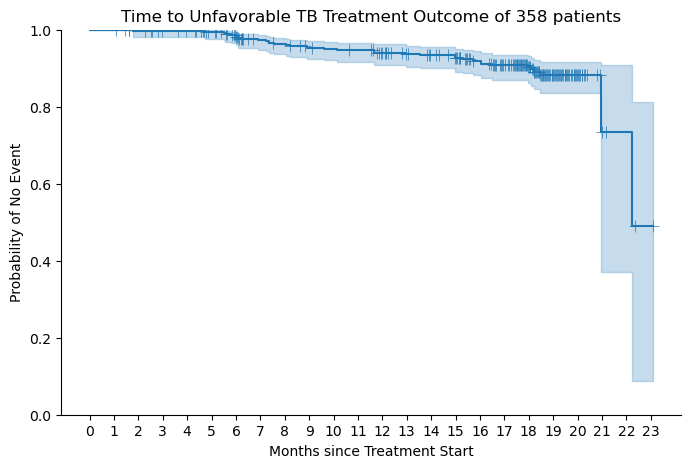

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))

final_keep_pids = df_samples_imputations[0].pid.values
df_final = df_final.query("pid in @final_keep_pids")

kmf_full = lifelines.KaplanMeierFitter()
kmf_full.fit(df_final['months'], event_observed=df_final['event'])
# print(kmf.median_survival_time_)
kmf_full.plot_survival_function(show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5})
# plt.ylim(0, 1)

# Set x-axis ticks to show all integers
# ax.set_xticks(range(0, df_final['weeks'].max() + 1))

plt.title(f"Time to Unfavorable TB Treatment Outcome of {df_final.pid.nunique()} patients")
plt.ylabel("Probability of No Event") #
plt.xlabel("Months since Treatment Start")


plt.ylim(0, 1)

# Set x-axis ticks to show all integers
ax.set_xticks(range(0, int(df_final['months'].max()) + 1))


plt.gca().get_legend().remove()

sns.despine()
plt.savefig("figures/KM_curve_tx_outcomes_all.svg", bbox_inches='tight')

In [75]:
# fig, ax = plt.subplots(figsize=(8, 5))

# kmf = lifelines.KaplanMeierFitter()

# stratify_col = 'event_type'

# color_dict = dict(zip(['tx_failure', 'death', 'relapse'], sns.color_palette('tab10')))
# labels_dict = {'tx_failure': 'Tx Failure', 'death': 'Death', 'relapse': 'Relapse'}

# for group in ['tx_failure', 'death', 'relapse']:

#     df_single_group = df_final.query(f"{stratify_col}==@group")

#     # exclude non-TB deaths that would be censored
#     # df_single_group = df_single_group.query("~(TB_death==0 & event==1)")

#     if group != 'cure':
#         kmf.fit(df_single_group['months'], event_observed=df_single_group['event'], label=group)
#         kmf.plot_survival_function(ax=ax, color=color_dict[group], show_censors=True, censor_styles={"marker": "+", "ms": 8, "mew": 0.5}, label=f"{labels_dict[group]} = {len(df_single_group)}")

# num_poor_event = df_final.query(f"event == 1").pid.nunique()# & pid in @df_samples.pid").pid.nunique()

# plt.title(f"Time to Unfavorable TB Treatment Outcome of {num_poor_event} patients")
# plt.ylabel("Probability of No Event") #
# plt.xlabel("Months since Treatment Start")

# plt.ylim(0, 1)

# # Set x-axis ticks to show all integers
# ax.set_xticks(range(0, int(df_final.query(f"event == 1")['months'].max()) + 1))

# sns.despine()
# plt.show()
# # plt.savefig("./figures/KM_curve_tx_outcomes.svg", bbox_inches='tight')

In [28]:
# # wow, not doing anything is fine for this model!!! So don't have to change it
# df_violating_covariates = []

# for model_idx in range(len(cph_models_imputations)):

#     df_proportional_hazards = lifelines.statistics.proportional_hazard_test(cph_models_imputations[model_idx], df_samples_imputations[model_idx], time_transform='rank').summary
    
#     # diabetes has a p-value of like 0.0105
#     violating_covariates = df_proportional_hazards.reset_index()[['index', 'p']].rename(columns={'index': 'covariate'})
    
#     violating_covariates['imp_num'] = model_idx + 1

#     df_violating_covariates.append(violating_covariates)

# df_violating_covariates = pd.concat(df_violating_covariates)

In [29]:
df_violating_covariates.query("p <= 0.01").covariate.unique()

array([], dtype=object)

In [81]:
TRUST_phenos.query("pid in ['T0114', 'T0244']")

,pid,RIF_lower_bound,RIF_upper_bound,RIF_midpoint,INH_lower_bound,INH_upper_bound,INH_midpoint,EMB_lower_bound,EMB_upper_bound,EMB_midpoint,PZA_lower_bound,PZA_upper_bound,PZA_midpoint
37,T0114,0.03,0.06,0.045,0.025,0.05,0.0375,0.6,1.25,0.925,NaN,NaN,NaN


# 1.1 Univariate Association Models

In [30]:
stratify_covariates = []

# df_univar_pvals_outcomes = pd.DataFrame(columns = ['pval'])

# for covar in cols_lst:

#     # need to stratify by these variables
#     if covar not in stratify_covariates:

#         print(f"Testing {covar}")
    
#         df_test_results, _, _ = fit_cox_models_all_imputations(df_trust_patients,
#                                                               df_pred_combined,
#                                                                TRUST_phenos,
#                                                                df_imputed,
#                                                               df_final,
#                                                               [covar] + stratify_covariates, # make sure to include stratify_covariates here as well otherwise it will fail
#                                                               event_col = 'event',
#                                                                 time_col = 'date',
#                                                               exclude_resistance=False,
#                                                               MIC_type='none',
#                                                               binarize_MICs=False,
#                                                               tb_deaths_only=True, 
#                                                               include_drugs=[],
#                                                               # cluster_col='household_num',
#                                          )


#         # could be two because of the HIV CD4 categorical variable
#         assert len(df_test_results) <= 2

#         df_univar_pvals_outcomes.loc[covar, 'pval'] = df_test_results['pval'].values[0]

# df_univar_pvals_outcomes.reset_index().rename(columns={'index': 'covariate'}).to_csv("./model_results/univariate_results_outcomes_TB_deaths_only.csv", index=False)
df_univar_pvals_outcomes = pd.read_csv("./model_results/univariate_results_outcomes_TB_deaths_only.csv")

Testing screen_sex
    Censored 6 patients with non-TB deaths
    358 total pids
Testing screen_years
    Censored 6 patients with non-TB deaths
    358 total pids
Testing bl_bmi
    Censored 6 patients with non-TB deaths
    358 total pids
Testing fstrom1_baseline
    Censored 6 patients with non-TB deaths
    358 total pids
Testing HIV_CD4
    Censored 6 patients with non-TB deaths
    358 total pids
Testing bl_prevtb
    Censored 6 patients with non-TB deaths
    358 total pids
Testing smear_pos_no_contam_sputum_specimen_1
    Censored 6 patients with non-TB deaths
    358 total pids
Testing diabetes
    Censored 6 patients with non-TB deaths
    358 total pids
Testing total_adherence
    Censored 6 patients with non-TB deaths
    358 total pids
Testing high_lung_involvement
    Censored 6 patients with non-TB deaths
    358 total pids
Testing RIF_AUC
    Censored 6 patients with non-TB deaths
    358 total pids
Testing cxr_cavity_chest_radiograph_1
    Censored 6 patients with non-

## 1. LRT to prune the patient covariates from the model

In [31]:
# df_LRT_pvals_outcomes = pd.DataFrame(columns = ['pval'])

# for covar in cols_lst:

#     print(f"Testing {covar}")
    
#     pval = run_LRT_single_predictor(covar, 
#                                     df_trust_patients,
#                                     df_pred_combined,
#                                     TRUST_phenos,
#                                     df_imputed, 
#                                     df_final, 
#                                     cols_lst, 
#                                     event_col = 'event',
#                                     time_col = 'date',
#                                     tb_deaths_only=tb_deaths_only, 
#                                     MIC_type='none',
#                                     # cluster_col='household_num',
#                                    )
    
#     df_LRT_pvals_outcomes.loc[covar, 'pval'] = pval

# df_LRT_pvals_outcomes.reset_index().rename(columns={'index': 'covariate'}).to_csv("./model_results/LRT_results_outcomes_TB_deaths_only.csv", index=False)
df_LRT_pvals_outcomes = pd.read_csv("./model_results/LRT_results_outcomes_TB_deaths_only.csv")

Testing screen_sex
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-TB deaths
    358 total pids
Testing screen_years
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-TB deaths
    358 total pids
Testing bl_bmi
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-TB deaths
    358 total pids
Testing fstrom1_baseline
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-TB deaths
    358 total pids
Testing HIV_CD4
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-TB deaths
    358 total pids
Testing bl_prevtb
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-TB deaths
    358 total pids
Testing smear_pos_no_contam_sputum_specimen_1
    Censored 6 patients with non-TB deaths
    358 total pids
    Censored 6 patients with non-T

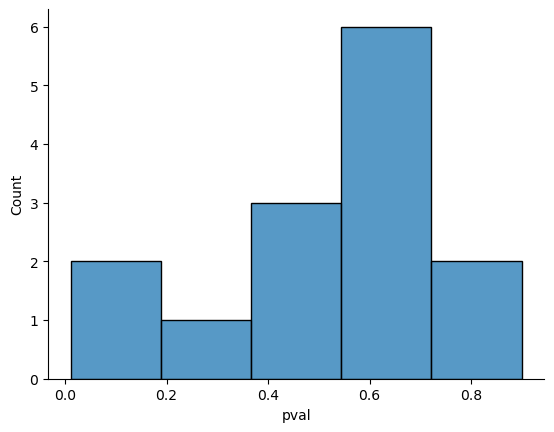

In [32]:
sns.histplot(data=df_univar_pvals_outcomes,
             x='pval'
            )

sns.despine()
plt.show()

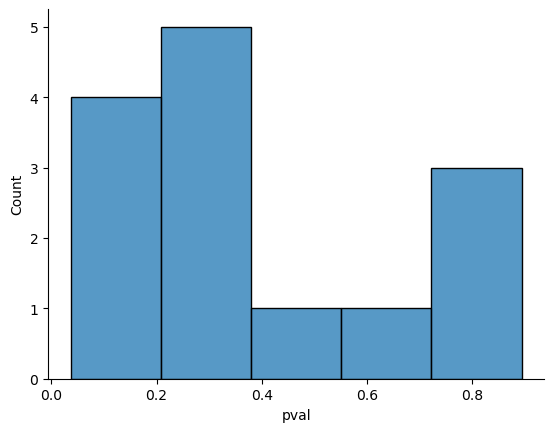

In [33]:
sns.histplot(data=df_LRT_pvals_outcomes,
             x='pval'
            )

sns.despine()
plt.show()

## 2. Fit a final patient covariate model with only the ones selected from the LRT, then add MICs to that

In [34]:
final_patient_predictors = list(df_LRT_pvals_outcomes.query("pval <= 0.2").covariate.values)

print(final_patient_predictors)

['HIV_CD4', 'total_adherence', 'F2']


In [35]:
exclude_resistance_lst = [0]
MIC_type_lst = ['measured', 'predicted']
binarize_MICs_lst = [False]#[True, False]
tb_deaths_only_lst = [tb_deaths_only]

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, binarize_MICs_lst, tb_deaths_only_lst, drugs_lst + [drugs_lst] + [['RIF', 'INH', 'EMB']]))

# param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, binarize_MICs_lst, tb_deaths_only_lst, ['RIF']))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'binarize_MICs': binarize_MICs,
     'tb_deaths_only': tb_deaths_only,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, binarize_MICs, tb_deaths_only, drug in param_grid
]

len(param_grid_dicts)

12

In [36]:
df_outcomes_model_final = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

    # skip cases where MIC = measured and PZA is included because it drops the sample size
    if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
        print("    Skipping model")

    else:
        df_model_results, df_samples_imputations, _ = fit_cox_models_all_imputations(df_trust_patients,
                                                                                                      df_pred_combined,
                                                                                                       TRUST_phenos,
                                                                                      df_imputed,
                                                                          df_final,
                                                                          final_patient_predictors,
                                                                          event_col = 'event',
                                                                          time_col = 'date',
                                                                          exclude_resistance=params_lst['exclude_resistance'],
                                                                          MIC_type=params_lst['MIC_type'],
                                                                          binarize_MICs=params_lst['binarize_MICs'],
                                                                          tb_deaths_only=params_lst['tb_deaths_only'],
                                                                          include_drugs=params_lst['include_drugs_lst'],
                                                                          # cluster_col='household_num',
                                                                                     invert_OR=False,
                                                                         )
    
        predictors_lst = df_model_results.covariate.values
    
        df_model_results['exclude_resistance'] = params_lst['exclude_resistance']
        df_model_results['MIC_type'] = params_lst['MIC_type']
        df_model_results['binarize_MICs'] = params_lst['binarize_MICs']
        df_model_results['tb_deaths_only'] = params_lst['tb_deaths_only']
        df_model_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
        df_model_results['num_pids'] = df_samples_imputations[0]['pid'].nunique()
        
        df_outcomes_model_final.append(df_model_results)

df_outcomes_model_final = pd.concat(df_outcomes_model_final)

# annotate significance
df_outcomes_model_final.loc[(df_outcomes_model_final["pval"] <= 0.05), 'significant'] = 1

df_outcomes_model_final.to_csv("./model_results/tx_outcomes_TB_deaths_only.csv", index=False)

Model 1
    Censored 6 patients with non-TB deaths
    357 total pids
Model 2
    Censored 6 patients with non-TB deaths
    357 total pids
Model 3
    Censored 6 patients with non-TB deaths
    357 total pids
Model 4
    Skipping model
Model 5
    Skipping model
Model 6
    Censored 6 patients with non-TB deaths
    357 total pids
Model 7
    Censored 6 patients with non-TB deaths
    358 total pids
Model 8
    Censored 6 patients with non-TB deaths
    358 total pids
Model 9
    Censored 6 patients with non-TB deaths
    358 total pids
Model 10
    Censored 6 patients with non-TB deaths
    358 total pids
Model 11
    Censored 6 patients with non-TB deaths
    358 total pids
Model 12
    Censored 6 patients with non-TB deaths
    358 total pids


In [38]:
df_outcomes_model_final.query("significant==1")['covariate'].unique()

array(['HIV_Low_CD4', 'total_adherence'], dtype=object)

In [40]:
df_pred_combined[['RIF_pred_MIC', 'INH_pred_MIC', 'EMB_pred_MIC', 'PZA_pred_MIC']].mean()

RIF_pred_MIC     0.058412
INH_pred_MIC     0.093964
EMB_pred_MIC     1.203636
PZA_pred_MIC    23.357083
dtype: float64

In [41]:
df_pred_combined.pid.nunique()

403

In [42]:
# transform some hazard ratios for interpretability
# # 1. F2: by 0.5, which is the full range?
# df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='F2', ['OR', 'OR_lower', 'OR_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='F2', ['OR', 'OR_lower', 'OR_upper']]**0.5

OR_col = 'OR'

# # 2. Adherence rate: by 0.1
# df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='adherence_rate', ['OR', 'OR_lower', 'OR_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']=='adherence_rate', ['OR', 'OR_lower', 'OR_upper']]**0.1

# MIC HRs should be transformed to per 0.01 µg/mL for RIF, INH, and EMB and per 10 µg/mL for PZA  
# transform the confidence intervals for the predicted MICs to per 0.01, as they did in the NEJM paper
df_outcomes_model_final = pd.read_csv("./model_results/tx_outcomes_TB_deaths_only.csv")

for col in np.concatenate([df_outcomes_model_final.query("covariate.str.endswith('_midpoint') | covariate.str.endswith('_pred_MIC')").covariate.unique(), np.array(['F2'])]):

    if col == 'F2':
        multiply_factor = 0.5
    else:
        multiply_factor = 0.1

    print(col, multiply_factor)
    
    df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']] = df_outcomes_model_final.loc[df_outcomes_model_final['covariate']==col, [OR_col, f'{OR_col}_lower', f'{OR_col}_upper']]**multiply_factor

RIF_midpoint 0.1
INH_midpoint 0.1
EMB_midpoint 0.1
RIF_pred_MIC 0.1
INH_pred_MIC 0.1
EMB_pred_MIC 0.1
PZA_pred_MIC 0.1
F2 0.5


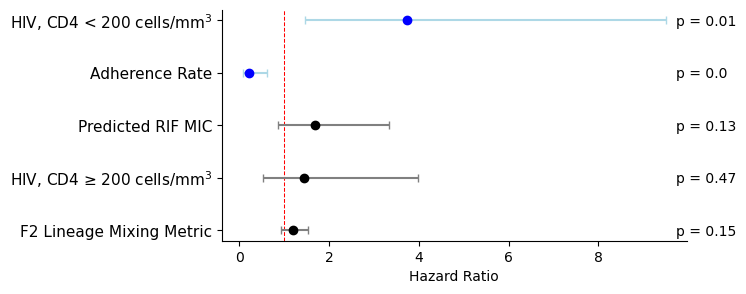

In [43]:
forest_plot(df_outcomes_model_final.query("MIC_type=='predicted' & tb_deaths_only==True & include_drugs=='RIF'"))

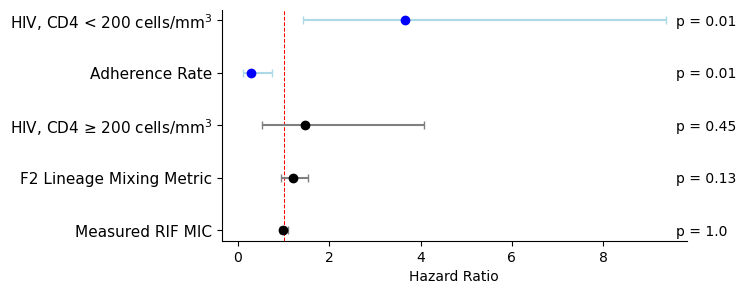

In [44]:
forest_plot(df_outcomes_model_final.query("MIC_type=='measured' & tb_deaths_only==True & include_drugs=='RIF'"))

In [45]:
forest_plot(df_outcomes_model_final.query("MIC_type=='predicted' & tb_deaths_only==True & include_drugs=='RIF,INH,EMB,PZA'"), saveName="./figures/tx_outcomes_predicted_MIC.svg")

In [46]:
forest_plot(df_outcomes_model_final.query("MIC_type=='measured' & tb_deaths_only==True & include_drugs=='RIF,INH,EMB'"), saveName="./figures/tx_outcomes_measured_MIC.svg")

# Binary Model for Poor Outcomes

In [172]:
def fit_multivariate_logit_model(df_model, df_outcome, cols_lst, MIC_type='none', include_drugs=drugs_lst):

    # Process input features
    df_model_processed, features_lst = process_input_features_for_model(df_model, cols_lst, MIC_type=MIC_type, include_drugs=include_drugs)
    
    # Add outcome data
    df_model_processed = df_model_processed.merge(df_outcome, on='pid')
    df_model_processed_save = df_model_processed.copy()

    # remove any columns that are the same everywhere to reduce model fitting time
    remove_cols = df_model_processed.columns[df_model_processed.nunique() == 1]
    # print(f"    Removing features {remove_cols} because they are the same everywhere")
    features_lst = list(set(features_lst) - set(remove_cols))

    # keep track of these for un-normalizing the final odds ratios
    means_dict = dict(df_model_processed[features_lst].mean(axis=0))
    std_dict = dict(df_model_processed[features_lst].std(axis=0))
    
    # Normalize features
    scaler = StandardScaler()
    X = scaler.fit_transform(df_model_processed[features_lst])
    y = df_model_processed['event'].values
    
    # Add a constant (intercept) to the model
    X = sm.add_constant(X)

    # add class weighting
    class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
    
    # sample level weights
    weights = np.where(y == 1, class_weights[1], class_weights[0])
    
    # Fit the logistic regression model using statsmodels
    model = sm.Logit(y, X)
    result = model.fit(weights=weights, maxiter=1000, cov_type='cluster', cov_kwds={'groups': df_model_processed['unique_patient']}, disp=0)
    
    # Get confidence intervals for the coefficients
    # conf_int = result.conf_int()
    # conf_int_exp = np.exp(conf_int)  # Exponentiate to get odds ratio confidence intervals
    
    df_model_results = pd.DataFrame({'covariate': ['intercept'] + features_lst, 
                                    'coef': result.params, 
                                    # 'OR': np.exp(result.params), 
                                    'pval': result.pvalues, 
                                    'std_error': result.bse, # standard errors
                                   })
    
    # # df_coef = pd.concat([df_coef, pd.DataFrame(conf_int_exp)], axis=1)
    # # df_coef.columns = ['covariate', 'coef' 'std_error']

    # return df_coef, df_model_processed#, df_exclude
    
    # Transform coefficients to original scale. Fill NA (only the intercept feature) with 1 so that the transformed coef and se aren't changed
    df_model_results['original_mean'] = df_model_results['covariate'].map(means_dict).fillna(1)
    df_model_results['original_std'] = df_model_results['covariate'].map(std_dict).fillna(1)
    df_model_results['coef_transformed'] = df_model_results['coef'] / df_model_results['original_std']
    df_model_results['se_transformed'] = df_model_results['std_error'] / df_model_results['original_std']
    
    return df_model_results, df_model_processed_save

In [277]:
def fit_multivariate_logit_model_all_imputations(df_trust_patients, df_pred_combined, TRUST_phenos, df_imputed, df_outcome, cols_lst, alpha=0.05, exclude_resistance=False, MIC_type=None, binarize_MICs=False, include_drugs=[], tb_deaths_only=False, original_dataset_only=False):
    '''
    tb_deaths_only: if True, consider only TB-related deaths as among the treatment failure group, so exclude patients with deaths from other causes
    '''

    df_estimates = []
    df_outcome_copy = df_outcome.copy()

    coef_col = 'coef_transformed'
    se_col = 'se_transformed'

    df_estimates = []

    # keep track of log-likelihoods across imputations because need to match them to get the difference between nested models
    log_like_imputations = []
    df_model_processed_imputations = [] # need to keep track of the individual training datasets as well for testing the proportional hazards assumptions
    
    # restrict to samples that were collected in the first 2 weeks
    df_WGS_info = df_trust_patients[['pid', 'Original_ID', 'SampleID', 'Lineage', 'F2']]

    # preferentialy keep the first WGS sample for each one. Sort by Lineage with NAs last to preferentially keep the first uncontaminated sample. Contaminated samples are NA in the Lineage column
    df_WGS_info = df_WGS_info.sort_values(['pid', 'Lineage', 'Original_ID'], na_position='last').drop_duplicates(subset=['pid'], keep='first')

    if tb_deaths_only:

        non_tb_death_pids = df_outcome_copy.query("event_type == 'death' & TB_death == 0").pid.unique()
        print(f"    Censored {len(non_tb_death_pids)} patients with non-TB deaths")

        # censor the patients who died of non-TB causes
        df_outcome_copy.loc[df_outcome_copy['pid'].isin(non_tb_death_pids), 'event'] = 0

    # only use the original dataset
    if original_dataset_only:
        imp_lst = [0]
    else:
        imp_lst = np.sort(df_imputed['.imp'].unique())[1:]
    
    # skip the first one because it's the initializing one. There will be N + 1 unique values in the .imp column
    for imp_num in imp_lst:

        # combine with lineage and F2 information and remove highly contaminated WGS (which will be NaN in those columns)
        df_single_imputation = df_imputed.loc[df_imputed['.imp']==imp_num].merge(df_WGS_info[['pid', 'Lineage', 'SampleID', 'F2']])

        if 'imp_num' in df_outcome.columns:
            df_outcome_single_imputation = df_outcome.query("imp_num==@imp_num")
        else:
            df_outcome_single_imputation = df_outcome.copy()

        # add measured and predicted MICs, then the process_input_features_for_model function will keep only those that should be here, determined by the MIC_type argument
        df_single_imputation = df_single_imputation.merge(TRUST_phenos, on='pid').merge(df_pred_combined, on='pid')

        if exclude_resistance:
            
            # remove all pids with measured resistant MICs
            for col in df_single_imputation.columns[df_single_imputation.columns.str.contains('_upper_bound')]:
                
                drug = col.split("_")[0]

                drug_full_name = abbr_drug_dict[drug]
                
                # all measured MICs have been normalized to MGIT, which is the majority medium. So get the critical concentration for MGIT
                mgit_cc = cc_df.query("Medium=='MGIT' & Drug==@drug_full_name").Value.values[0]
    
                # keep only pids where the upper bound is less than or equal to the critical concentration.
                # Do the inverse (exclude pids where the upper bound is greater than the CC because of MICs that are NA
                # print(drug, mgit_cc, len(df_single_imputation.query(f"~({drug}_upper_bound > @mgit_cc)")))
                num_measured_resistant = df_single_imputation.query(f"{drug}_upper_bound > @mgit_cc").pid.nunique()
                df_single_imputation = df_single_imputation.query(f"~({drug}_upper_bound > @mgit_cc)")

                isolates_with_genotypic_resistance = df_WHO_variants.query("drug==@drug_full_name").SampleID.values
                num_genotypic_resistant = df_single_imputation.query("SampleID in @isolates_with_genotypic_resistance").pid.nunique()
                df_single_imputation = df_single_imputation.query("SampleID not in @isolates_with_genotypic_resistance")

                if imp_num in [0, 1]:
                    print(f"    Dropped {num_measured_resistant} patients with measured and {num_genotypic_resistant} patients with genotypic {drug} resistance")
                    
        df_model_results, df_model_processed = fit_multivariate_logit_model(df_single_imputation, 
                                                                           df_outcome_single_imputation, 
                                                                           cols_lst, 
                                                                           MIC_type=MIC_type, 
                                                                           include_drugs=include_drugs
                                                                          )

        if imp_num in [0, 1]:
            print(f"{df_model_processed.pid.nunique()} patients")

        df_save = df_model_results[['covariate', coef_col, se_col]]
        df_save['imp_num'] = imp_num
        df_estimates.append(df_save.reset_index())
        df_model_processed_imputations.append(df_model_processed)

    df_estimates = pd.concat(df_estimates)
    # print(df_estimates)

    # finally, pool results across the models. Doesn't matter which dataframe you take the length of, they all have the same pids
    if not original_dataset_only:
        return pool_imputation_results(df_estimates, df_imputed.pid.nunique(), coef_col, se_col, alpha, invert_OR=False), df_model_processed_imputations

    else:
        # add p-values. The Wald stat follows the normal distribution
        # survival function = 1 - CDF, which is the probability of being greater than the critical value. Take the absolute value so that you get the positive z-score
        df_estimates['pval'] = 2 * st.norm.sf(np.abs(df_estimates[coef_col] / df_estimates[se_col]))

        # add confidence intervals
        df_estimates['OR'] = np.exp(df_estimates[coef_col])
        df_estimates['OR_lower'] = np.exp(df_estimates[coef_col] + st.norm.ppf(alpha / 2) * df_estimates[se_col])
        df_estimates['OR_upper'] = np.exp(df_estimates[coef_col] + st.norm.ppf(1 - alpha / 2) * df_estimates[se_col])

        return df_estimates, df_model_processed

In [274]:
df_binary_outcome = df_final.query("event==1 | (event == 0 & event_type=='cure')")
df_binary_outcome.pid.nunique()

425

In [275]:
# df_logit_model_results, _ = fit_multivariate_logit_model(df_imputed, df_binary_outcome, cols_lst, MIC_type='none')

In [286]:
df_binary_model_results, _ = fit_multivariate_logit_model_all_imputations(df_trust_patients, 
                                                                          df_pred_combined, 
                                                                          TRUST_phenos, 
                                                                          df_imputed,
                                                                          df_binary_outcome, 
                                                                          cols_lst, 
                                                                          MIC_type='none', 
                                                                          include_drugs=[], 
                                                                          tb_deaths_only=True,
                                                                          original_dataset_only=False
                                                                         )

    Censored 6 patients with non-TB deaths
351 patients


<Axes: xlabel='pval', ylabel='Count'>

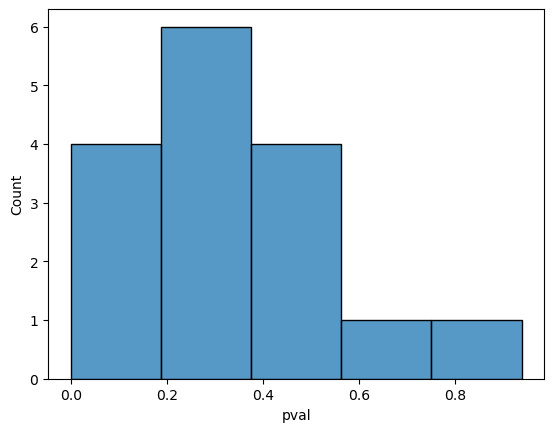

In [287]:
sns.histplot(data=df_binary_model_results,
             x='pval'
            )

In [288]:
final_binary_patient_predictors = df_binary_model_results.query("pval <= 0.3 & covariate != 'intercept'").covariate.values

print(np.sort(final_binary_patient_predictors))

['HIV_High_CD4' 'HIV_Low_CD4' 'bl_prevtb' 'diabetes' 'total_adherence']


In [289]:
exclude_resistance_lst = [0]
MIC_type_lst = ['measured', 'predicted']
binarize_MICs_lst = [False]#[True, False]
tb_deaths_only_lst = [tb_deaths_only]

param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, binarize_MICs_lst, tb_deaths_only_lst, drugs_lst + [drugs_lst] + [['RIF', 'INH', 'EMB']]))

# param_grid = list(itertools.product(exclude_resistance_lst, MIC_type_lst, binarize_MICs_lst, tb_deaths_only_lst, ['RIF']))

# If you prefer the result as a list of dictionaries (one for each combination):
param_grid_dicts = [
    {
     'exclude_resistance': exclude_resistance,
     'MIC_type': MIC_type,
     'binarize_MICs': binarize_MICs,
     'tb_deaths_only': tb_deaths_only,
     'include_drugs_lst': [drug] if type(drug) != list else drug # try each drug individuallly and also all of them together
    }
    for exclude_resistance, MIC_type, binarize_MICs, tb_deaths_only, drug in param_grid
]

len(param_grid_dicts)

12

In [290]:
df_outcomes_binary_model_final = []

for i, params_lst in enumerate(param_grid_dicts):

    print(f"Model {i+1}")

    # skip cases where MIC = measured and PZA is included because it drops the sample size
    if params_lst['MIC_type'] == 'measured' and 'PZA' in params_lst['include_drugs_lst']:
        print("    Skipping model")

    else:
        df_binary_model_results, df_binary_samples_imputations = fit_multivariate_logit_model_all_imputations(df_trust_patients, 
                                                                                  df_pred_combined, 
                                                                                  TRUST_phenos, 
                                                                                  df_imputed,
                                                                                  df_binary_outcome, 
                                                                                  cols_lst, 
                                                                                  MIC_type=params_lst['MIC_type'], 
                                                                                  include_drugs=params_lst['include_drugs_lst'], 
                                                                                  tb_deaths_only=True,
                                                                                                              original_dataset_only=False
                                                                                 )
    
        predictors_lst = df_model_results.covariate.values
    
        # df_binary_model_results['exclude_resistance'] = params_lst['exclude_resistance']
        df_binary_model_results['MIC_type'] = params_lst['MIC_type']
        # df_binary_model_results['binarize_MICs'] = params_lst['binarize_MICs']
        # df_binary_model_results['tb_deaths_only'] = params_lst['tb_deaths_only']
        df_binary_model_results['include_drugs'] = ','.join(params_lst['include_drugs_lst'])
        df_binary_model_results['num_pids'] = df_binary_samples_imputations[0]['pid'].nunique()
        
        df_outcomes_binary_model_final.append(df_binary_model_results)

df_outcomes_binary_model_final = pd.concat(df_outcomes_binary_model_final)

# annotate significance
df_outcomes_binary_model_final.loc[(df_outcomes_binary_model_final["pval"] <= 0.05), 'significant'] = 1

results_fName = "./model_results/tx_outcomes"

if tb_deaths_only:
    tb_deaths_suffix = '_TB_deaths_only'
else:
    tb_deaths_suffix = ''

if exclude_high_F2:
    mixed_infect_suffix = '_no_mixed_infect'
else:
    mixed_infect_suffix = ''

results_fName = f"{results_fName}{tb_deaths_suffix}_binary.csv"

df_outcomes_binary_model_final.to_csv(results_fName, index=False)

Model 1
    Censored 6 patients with non-TB deaths
351 patients
Model 2
    Censored 6 patients with non-TB deaths
351 patients
Model 3
    Censored 6 patients with non-TB deaths
351 patients
Model 4
    Skipping model
Model 5
    Skipping model
Model 6
    Censored 6 patients with non-TB deaths
351 patients
Model 7
    Censored 6 patients with non-TB deaths
351 patients
Model 8
    Censored 6 patients with non-TB deaths
351 patients
Model 9
    Censored 6 patients with non-TB deaths
351 patients
Model 10
    Censored 6 patients with non-TB deaths
351 patients
Model 11
    Censored 6 patients with non-TB deaths
351 patients
Model 12
    Censored 6 patients with non-TB deaths
351 patients


In [293]:
df_outcomes_binary_model_final.query("significant==1").covariate.unique()

array(['intercept', 'total_adherence'], dtype=object)

In [292]:
results_fName

'./model_results/tx_outcomes_TB_deaths_only_binary.csv'